# Get started in 10 minutes 🚀

Welcome! 👋  
In this short, hands-on tutorial you’ll get your first taste of **ERA5-Drought** and learn how to create a **global snapshot of current drought conditions** — in just a few minutes.

The goal isn’t to learn everything.  
The goal is to **get something meaningful working, fast.**

Ready? Let’s dive in.

## Setting the scene

Imagine you’re part of a disaster-response or climate-monitoring team.  
Your colleagues ask a simple but urgent question:

> **“Where in the world is it unusually dry right now?”**

You don’t need a full climate model or to sift through dozens of datasets.  
You just need a clear, data-driven picture — quickly.

This is where **ERA5-Drought** comes in.

### ❓ The question  
We want to understand the **current** drought conditions worldwide. More precisely, we want to identify regions where the **last month** has been **drier than usual**.

### 💧 The index: Standardized Precipitation Index (SPI)

One of the most widely used ways to quantify short-term drought is the **Standardized Precipitation Index (SPI)**.  

::: tip SPI at a glance
**Standardized Precipitation Index (SPI)**

The SPI measures how unusual precipitation is over a given period compared to a historical baseline.

**Interpretation of SPI values:**

- **> 2.0** → Extremely wet
- **1.5 – 1.99** → Very wet
- **1.0 – 1.49** → Moderately wet
- **-0.99 – 0.99** → Near normal
- **-1.0 – -1.49** → Moderately dry
- **-1.5 – -1.99** → Severely dry
- **< -2.0** → Extremely dry

We will focus on **SPI-1** (1-month accumulation) for the latest drought snapshot.
:::

---

### How it works

- We look at the **precipitation over a specific period** (here, 1 month).  
- Compare it to the **same month over a historical baseline** (typically 1991–2020).  
- Ask:  
  **“Was this month unusually dry? Or wetter than normal?”**

The resulting SPI values are easy to interpret:
- **Negative SPI** → drier than normal  
- **Positive SPI** → wetter than normal  
- **Around zero** → typical conditions  

With this in hand, we can now move on to download the latest SPI-1 data and start visualizing the current global drought patterns.

## Download latest SPI-1 snapshot from ERA5-Drought

Now that we know what SPI is, let's get our hands on some real data!  
We'll download the latest **SPI-1 snapshot** from ERA5-Drought using the **ERA5T intermediate release**.

At the time of writing, the most recent snapshot is from **October 2025**, which always represents the end of the month.  
We'll use the **CDS API** to download the data. If you haven't set it up yet, you can find instructions [here]().  

The data will be stored in a file called:
`era5_drought_latest_snapshot.nc`
and contains SPI-1 values for **all land grid points globally** for the selected month.


In [12]:
import cdsapi
import zipfile
import os

# File names
zip_file = "era5_drought_latest_snapshot.zip"
nc_file = "SPI1_gamma_global_era5t_moda_ref1991to2020_202510.nc"  # inside the zip

dataset = "derived-drought-historical-monthly"
request = {
    "variable": ["standardised_precipitation_index"],
    "accumulation_period": ["1"],
    "version": "1_0",
    "product_type": ["reanalysis"],
    "dataset_type": "intermediate_dataset",
    "year": ["2025"],
    "month": ["10"]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(era5d_file)

# Extract the NetCDF file from the zip
with zipfile.ZipFile(zip_file, 'r') as z:
    z.extract(nc_file, path=".")

print(f"Data extracted to {nc_file}")

2025-11-28 14:07:10,574 WARNING [2025-10-30T00:00:00] Downloading data from this dataset requires that the user be registered with the CDS. The use of the API requires a CDS API key.
2025-11-28 14:07:10,575 INFO Request ID is ca5f428f-cc33-4ead-8e29-1f298a65df6c
2025-11-28 14:07:10,603 INFO status has been updated to accepted
2025-11-28 14:07:19,015 INFO status has been updated to successful


6a1b3fe2271365ab5663675bd37475a6.zip:   0%|          | 0.00/7.95M [00:00<?, ?B/s]

Data extracted to SPI1_gamma_global_era5t_moda_ref1991to2020_202510.nc


**What just happened?**

1. We specified the dataset (`derived-drought-historical-monthly` → ERA5-Drought) and the variable we are interested in (SPI → `standardised_precipitation_index`).
2. We requested the 1-month accumulation SPI (→ `accumulation_period: [1]`).
3. Using the CDS API, we downloaded the file to → `era5_drought_latest_snapshot.nc`.

Once this cell finishes running, you'll have a complete global SPI-1 snapshot ready for visualization and analysis!

## Read the data

With the data downloaded, the next step is to load it into Python and get a feel for its structure.
We’ll use xarray, which makes working with multi-dimensional NetCDF data easy.

In [14]:
import xarray as xr

# Open the downloaded SPI NetCDF file
ds = xr.open_dataset(nc_file)

# Take a quick look at the dataset
ds

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 1, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-10-01T06:00:00
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    SPI1     (time, lat, lon) float64 8MB ...
Attributes: (12/17)
    title:                   SPI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 14/11/2025 12:46:22 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    extent:                  -180,-90,180,90
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int

### Explore the dataset
`ds` contains a 3D array with the name `SPI1` with dimensions time, lat, lon. 

You can quickly inspect a slice, for example selecting a time step:
```python
ds['SPI1'].isel(time=0)
```
Since we only downloaded one time step, `ds` also only contains one time step. 

This is a great moment to check that the data loaded correctly and understand its structure before plotting.

## Plot a map of the SPI-1

Now comes the fun part: creating a global map of drought conditions using SPI-1!

We’ll use matplotlib and cartopy for plotting:

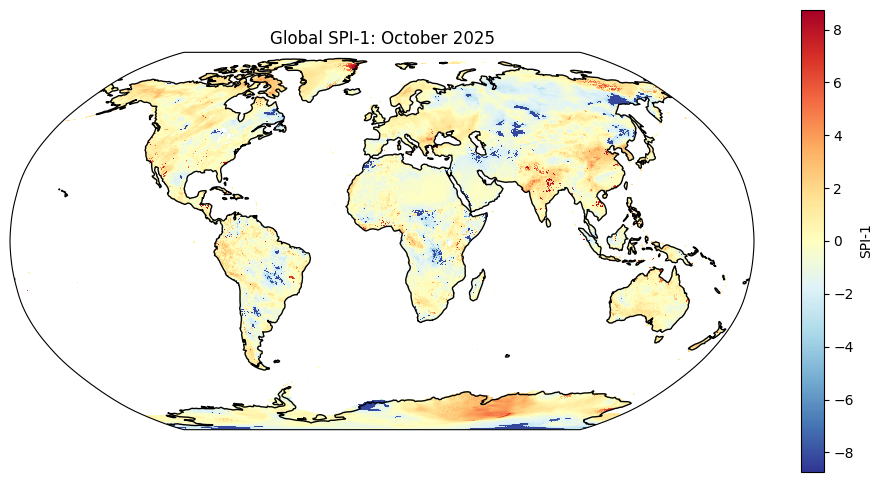

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Select the SPI-1 variable for the first (and only) time slice
spi1 = ds['SPI1'].isel(time=0)

# Create the figure
plt.figure(figsize=(12,6))

ax = plt.axes(projection=ccrs.Robinson())
spi1.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',   # Blue for wet, red for dry
    cbar_kwargs={'label': 'SPI-1'}
)
ax.coastlines()
ax.set_title("Global SPI-1: October 2025")
plt.show()

**What this map shows**

Red areas → regions drier than normal
Blue areas → wetter than normal
Near zero → typical conditions

With just a few lines of code, you now have a global snapshot of current drought conditions.

This map can help you quickly identify hotspots where rainfall has been unusually low, ready for further analysis or reporting.

## Wrapping up

Congratulations! 🎉  

In just a few minutes, you’ve:

- Learned what the **Standardized Precipitation Index (SPI)** is and how to interpret it.  
- Downloaded the latest **global SPI-1 snapshot** from ERA5-Drought.  
- Loaded the data into Python and explored its structure.  
- Created a **global map highlighting current drought conditions**.

This is just the beginning. From here, you could:

- Zoom into a region of interest to track local drought trends.  
- Compare SPI across multiple months to see how drought develops over time.  
- Combine SPI with other indicators for more comprehensive drought assessments.  

With these steps, you now have a **fast, data-driven way to monitor drought worldwide**, ready to support further analysis, research, or decision-making.